<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/Yfinance_stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf

data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

/tmp/ipykernel_2363/3825810033.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [2]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200
...,...,...,...,...,...
2023-12-22,191.609482,193.400870,190.985954,193.173224,37149600
2023-12-26,191.065140,191.896500,190.847401,191.619380,28919300


In [3]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [4]:
data['Close'].values

array([[ 72.4005127 ],
       [ 71.69664764],
       [ 72.26795197],
       ...,
       [191.16404724],
       [191.58966064],
       [190.55046082]])

In [5]:
data['Close'].index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
               '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
               '2023-12-28', '2023-12-29'],
              dtype='datetime64[ns]', name='Date', length=1006, freq=None)

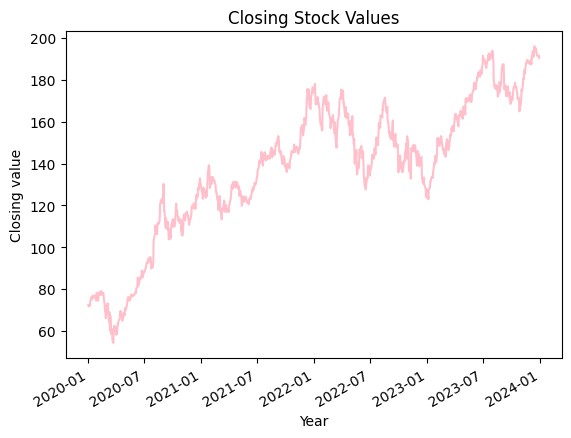

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

plt.plot(pd.to_datetime(data['Close'].index), data['Close'].values, c="pink")
plt.title("Closing Stock Values")
plt.xlabel("Year")
plt.ylabel("Closing value")
plt.gcf().autofmt_xdate()
plt.show()

In [7]:
import numpy as np

X = data['Close'].values
X.shape

(1006, 1)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

In [9]:
window_size = 60
x = []
y = []

for i in range(window_size, len(data_scaled)):
  x.append(data_scaled[i - window_size : i, 0])
  y.append(data_scaled[i, 0])

X, Y = np.array(x), np.array(y)

In [10]:
X, Y[:5]

(array([[-1.96625768, -1.98736862, -1.97023355, ..., -2.35846038,
         -2.26482793, -2.3423714 ],
        [-1.98736862, -1.97023355, -1.98042782, ..., -2.26482793,
         -2.3423714 , -2.29113475],
        [-1.97023355, -1.98042782, -1.94572475, ..., -2.3423714 ,
         -2.29113475, -2.29490331],
        ...,
        [ 1.01313934,  0.97311741,  1.0104703 , ...,  1.64122146,
          1.60916272,  1.59283634],
        [ 0.97311741,  1.0104703 ,  1.04752754, ...,  1.60916272,
          1.59283634,  1.59580286],
        [ 1.0104703 ,  1.04752754,  1.12401314, ...,  1.59283634,
          1.59580286,  1.60856823]]),
 array([-2.29113475, -2.29490331, -2.3918692 , -2.36273579, -2.3882456 ]))

In [11]:
X.shape

(946, 60)

In [12]:
x = np.reshape(X, (X.shape[0], X.shape[1], 1))
x.shape

(946, 60, 1)

In [13]:
import torch

X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(Y).float()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2)
len(X_train), len(X_test)

(756, 190)

In [15]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [16]:
X_train.shape

torch.Size([756, 60, 1])

In [17]:
from torch import nn

class RNN_Model(nn.Module):
  def __init__(self, input_u, output_u, hidden_u):
    super(RNN_Model, self).__init__()
    self.rnn = nn.RNN(input_u, hidden_u, batch_first=True)
    self.linear = nn.Linear(hidden_u, output_u)
  def forward(self, x):
    out, _ = self.rnn(x)
    out = self.linear(out[:, -1, :])
    return out

In [18]:
rnn_model = RNN_Model(input_u=1, output_u=1, hidden_u=32)
rnn_model

RNN_Model(
  (rnn): RNN(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [19]:
from torch.nn import MSELoss
from torch.optim import Adam

criterion = MSELoss()
optimizer = Adam(params=rnn_model.parameters(), lr=0.001)

In [20]:
for epoch in range(1000):
  rnn_model.train()
  pred = rnn_model(X_train)
  loss = criterion(pred, y_train.unsqueeze(1))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"\n__epoch___{epoch}")
    print(f"\nLoss: {loss.item():.5f}")


__epoch___0

Loss: 0.68731

__epoch___100

Loss: 0.01446

__epoch___200

Loss: 0.01093

__epoch___300

Loss: 0.00972

__epoch___400

Loss: 0.00890

__epoch___500

Loss: 0.00832

__epoch___600

Loss: 0.00791

__epoch___700

Loss: 0.00759

__epoch___800

Loss: 0.00733

__epoch___900

Loss: 0.00710


In [21]:
with torch.inference_mode():
  pred = rnn_model(X_test)

len(pred)

190

In [22]:
yt_values = scaler.inverse_transform(y_test.reshape(-1,1))
pred_values = scaler.inverse_transform(pred)

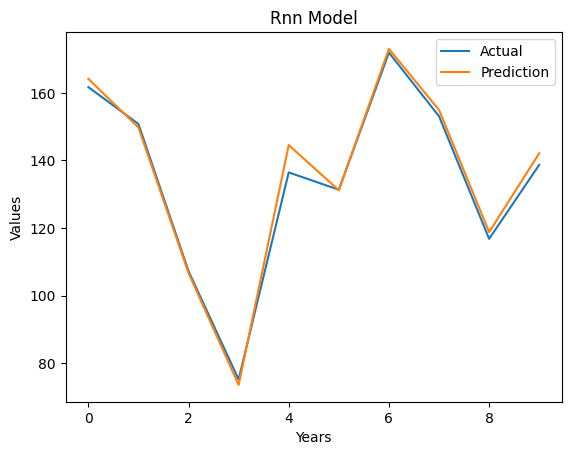

In [23]:
plt.plot(yt_values[:10], label="Actual")
plt.plot(pred_values[:10], label="Prediction")
plt.title("Rnn Model")
plt.xlabel("Years")
plt.ylabel("Values")
plt.legend()
plt.show()

In [24]:
class LSTM_Model(nn.Module):
  def __init__(self, input_u, output_u, hidden_u):
    super(LSTM_Model, self).__init__()
    self.lstm = nn.LSTM(input_u, hidden_u, batch_first=True)
    self.linear = nn.Linear(hidden_u, output_u)
  def forward(self, x):
    out, _ = self.lstm(x)
    out = self.linear(out[:, -1, :])
    return out

In [25]:
lstm_model = LSTM_Model(input_u=1, output_u=1, hidden_u=32)
lstm_model

LSTM_Model(
  (lstm): LSTM(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [26]:
from torch.nn import MSELoss
from torch.optim import Adam

criterion = MSELoss()
optimizer = Adam(params=lstm_model.parameters(), lr=0.001)

In [27]:
for epoch in range(1000):
  lstm_model.train()
  pred = lstm_model(X_train)
  loss = criterion(pred, y_train.unsqueeze(1))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"\n__epoch___{epoch}")
    print(f"\nLoss: {loss.item():.5f}")


__epoch___0

Loss: 0.85300

__epoch___100

Loss: 0.02582

__epoch___200

Loss: 0.01434

__epoch___300

Loss: 0.01203

__epoch___400

Loss: 0.01062

__epoch___500

Loss: 0.00952

__epoch___600

Loss: 0.00866

__epoch___700

Loss: 0.00803

__epoch___800

Loss: 0.00754

__epoch___900

Loss: 0.00714


In [28]:
with torch.inference_mode():
  pred = lstm_model(X_test)

len(pred)

190

In [29]:
yt_values = scaler.inverse_transform(y_test.reshape(-1,1))
pred_values = scaler.inverse_transform(pred)

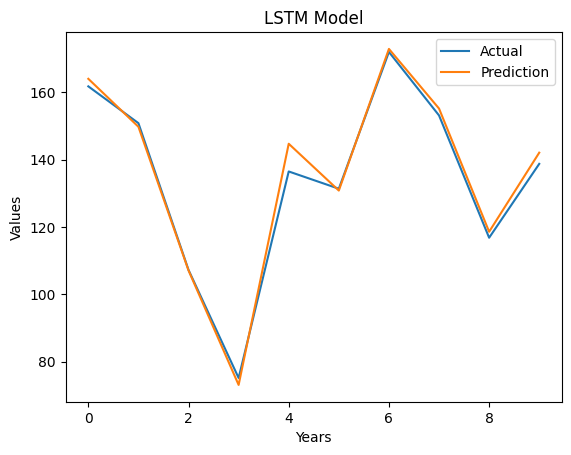

In [30]:
plt.plot(yt_values[:10], label="Actual")
plt.plot(pred_values[:10], label="Prediction")
plt.title("LSTM Model")
plt.xlabel("Years")
plt.ylabel("Values")
plt.legend()
plt.show()

In [31]:
class Bidirectional_LSTM_Model(nn.Module):
  def __init__(self, input_u, output_u, hidden_u):
    super(Bidirectional_LSTM_Model, self).__init__()
    self.bi_lstm = nn.LSTM(input_u, hidden_u, batch_first=True, bidirectional=True)
    self.linear = nn.Linear(hidden_u * 2, output_u)
  def forward(self, x):
    out, _ = self.bi_lstm(x)
    out = self.linear(out[:, -1, :])
    return out

In [32]:
bi_lstm_model = Bidirectional_LSTM_Model(input_u=1, output_u=1, hidden_u=32)
bi_lstm_model

Bidirectional_LSTM_Model(
  (bi_lstm): LSTM(1, 32, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

In [33]:
from torch.nn import MSELoss
from torch.optim import Adam

criterion = MSELoss()
optimizer = Adam(params=bi_lstm_model.parameters(), lr=0.001)

In [34]:
for epoch in range(1000):
  bi_lstm_model.train()
  pred = bi_lstm_model(X_train)
  loss = criterion(pred, y_train.unsqueeze(1))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"\n__epoch___{epoch}")
    print(f"\nLoss: {loss.item():.5f}")


__epoch___0

Loss: 0.88038

__epoch___100

Loss: 0.02402

__epoch___200

Loss: 0.01190

__epoch___300

Loss: 0.01010

__epoch___400

Loss: 0.00892

__epoch___500

Loss: 0.00813

__epoch___600

Loss: 0.00757

__epoch___700

Loss: 0.00710

__epoch___800

Loss: 0.00679

__epoch___900

Loss: 0.00656


In [35]:
with torch.inference_mode():
  pred = bi_lstm_model(X_test)

len(pred)

190

In [36]:
yt_values = scaler.inverse_transform(y_test.reshape(-1,1))
pred_values = scaler.inverse_transform(pred)

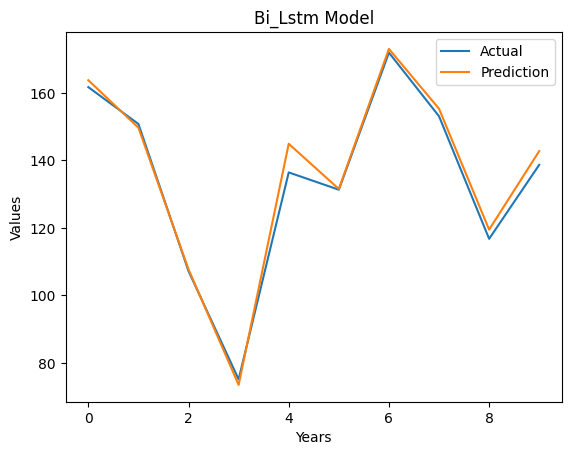

In [37]:
plt.plot(yt_values[:10], label="Actual")
plt.plot(pred_values[:10], label="Prediction")
plt.title("Bi_Lstm Model")
plt.xlabel("Years")
plt.ylabel("Values")
plt.legend()
plt.show()

In [38]:
class GRU_Model(nn.Module):
  def __init__(self, input_u, output_u, hidden_u):
    super(GRU_Model, self).__init__()
    self.gru = nn.GRU(input_u, hidden_u, batch_first=True)
    self.linear = nn.Linear(hidden_u, output_u)
  def forward(self, x):
    out, _ = self.gru(x)
    out = self.linear(out[:, -1, :])
    return out

In [39]:
gru_model = GRU_Model(input_u=1, output_u=1, hidden_u=32)
gru_model

GRU_Model(
  (gru): GRU(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [40]:
from torch.nn import MSELoss
from torch.optim import Adam

criterion = MSELoss()
optimizer = Adam(params=gru_model.parameters(), lr=0.001)

In [41]:
for epoch in range(1000):
  gru_model.train()
  pred = gru_model(X_train)
  loss = criterion(pred, y_train.unsqueeze(1))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"\n__epoch___{epoch}")
    print(f"\nLoss: {loss.item():.5f}")


__epoch___0

Loss: 0.86236

__epoch___100

Loss: 0.02197

__epoch___200

Loss: 0.01210

__epoch___300

Loss: 0.00992

__epoch___400

Loss: 0.00915

__epoch___500

Loss: 0.00858

__epoch___600

Loss: 0.00812

__epoch___700

Loss: 0.00775

__epoch___800

Loss: 0.00745

__epoch___900

Loss: 0.00720


In [42]:
with torch.inference_mode():
  pred = gru_model(X_test)

len(pred)

190

In [43]:
yt_values = scaler.inverse_transform(y_test.reshape(-1,1))
pred_values = scaler.inverse_transform(pred)

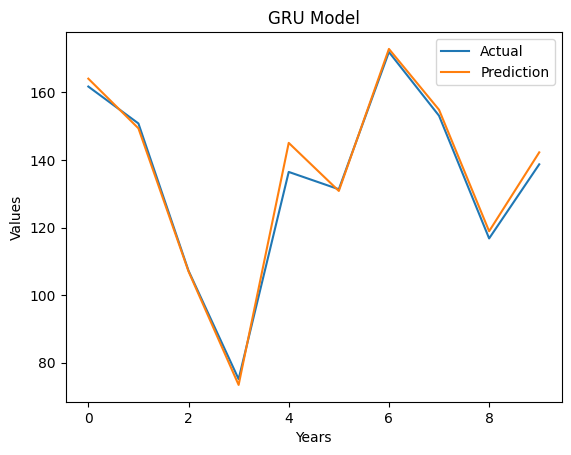

In [44]:
plt.plot(yt_values[:10], label="Actual")
plt.plot(pred_values[:10], label="Prediction")
plt.title("GRU Model")
plt.xlabel("Years")
plt.ylabel("Values")
plt.legend()
plt.show()